# Análise de Satisfação: Resolvendo o Conflito Pesquisa vs Web Scraping

## 🎯 Contexto do Problema

**Setembro/2025**: Dois relatos contraditórios sobre a satisfação dos clientes:

1. **Pesquisa de Satisfação**: Satisfação está MELHORANDO ✅
2. **Web Scraping (Comunicação)**: Reclamações AUMENTARAM ❌

## 🔍 Questões de Pesquisa

1. **Houve mudança real em setembro?** (teste de quebra estrutural)
2. **A satisfação melhorou ou piorou?** (análise de NSS temporal)
3. **Reclamações aumentaram?** (análise de negativos absolutos)
4. **Quem está certo?** Pesquisa, Comunicação, ou ambos?
5. **Por que a discrepância?** (viés de amostragem, métricas diferentes)

## 📊 Abordagem Metodológica

Baseado em princípios de **Behavioral Data Science** (Florent Buisson):

### 1. **Causal-Behavioral Framework**
- Satisfação **declarada** (pesquisa) ≠ Satisfação **revelada** (comentários)
- Social desirability bias em pesquisas
- Negativity bias em redes sociais

### 2. **Análise de Mudança Estrutural**
- Teste de quebra em setembro (Chow test)
- Análise antes/durante/depois
- Trends e sazonalidade

### 3. **Moderation Analysis**
- Tier modera a relação Tempo × Classificação?
- Grandes veículos reagiram diferente de pequenos?

### 4. **Segmentação Comportamental**
- Análise por Mídia (Site, Rádio, TV, Impresso)
- Análise por Categoria (Abastecimento, Obras, Atendimento...)
- Subcategorias críticas

---

In [34]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chisquare, ttest_ind, mannwhitneyu
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Bibliotecas carregadas")

Bibliotecas carregadas


## 1. Carregamento e Preparação dos Dados

In [35]:
# URL dos dados
url = "https://docs.google.com/spreadsheets/d/1LmMi0mTTzRytJno0EHu8P873wcPpQavktO_D_FFXA1E/export?format=xlsx&gid=1312481019"

# Carregar dados
df = pd.read_excel(url, engine='openpyxl')

print(f"Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Período: {df['Data'].min()} a {df['Data'].max()}")

Dataset carregado: 71,087 linhas × 15 colunas
Período: 2024-03-31 00:00:00 a 2025-03-31 00:00:00


In [36]:
# Preparação dos dados
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df['Ano_Mes'] = df['Data'].dt.to_period('M')
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia_Semana'] = df['Data'].dt.day_name()
df['Semana_do_Ano'] = df['Data'].dt.isocalendar().week

# Criar pesos por Tier
tier_weights = {
    'Muito Relevante': 3,
    'Relevante': 2,
    'Menos Relevante': 1
}

df['Peso'] = df['Tier'].map(tier_weights).fillna(1)

# Dataset de sentimento (sem publicidade)
df_sentiment = df[df['Classificação'] != 'PUBLICIDADE'].copy()

# Criar variável binária de negativo (para análise de reclamações)
df_sentiment['Is_Negativa'] = (df_sentiment['Classificação'] == 'NEGATIVA').astype(int)

# Definir períodos para análise de setembro
setembro_2025 = pd.Period('2025-09', freq='M')
df_sentiment['Periodo'] = df_sentiment['Ano_Mes'].apply(lambda x:
    'Antes' if x < setembro_2025 else
    'Setembro' if x == setembro_2025 else
    'Depois'
)

print(f"\n✅ Dados preparados:")
print(f"   Total de registros: {len(df):,}")
print(f"   Sentimento orgânico: {len(df_sentiment):,}")
print(f"   Publicidade excluída: {len(df) - len(df_sentiment):,}")


✅ Dados preparados:
   Total de registros: 71,087
   Sentimento orgânico: 70,007
   Publicidade excluída: 1,080


In [37]:
# Visão geral dos dados
print("="*80)
print("COLUNAS DO DATASET")
print("="*80)
print(df.dtypes)
print("\n" + "="*80)
print("PRIMEIRAS LINHAS")
print("="*80)
display(df.head())

COLUNAS DO DATASET
ID                                 int64
Tipo                              object
Conteúdo                          object
Data                      datetime64[ns]
Grupo                             object
Empresa                           object
Mídia                             object
Tier                              object
Veículo_de_comunicacao            object
Programa                          object
Categoria                         object
Subcategoria                      object
Classificação                     object
Título                            object
Arquivo/Link                      object
Ano_Mes                        period[M]
Ano                                int32
Mes                                int32
Dia_Semana                        object
Semana_do_Ano                     UInt32
Peso                             float64
dtype: object

PRIMEIRAS LINHAS


,ID,Tipo,Conteúdo,Data,Grupo,Empresa,Mídia,Tier,Veículo_de_comunicacao,Programa,Categoria,Subcategoria,Classificação,Título,Arquivo/Link,Ano_Mes,Ano,Mes,Dia_Semana,Semana_do_Ano,Peso
0,600740,Notícias/Publicações,Imprensa,2024-03-31,Aegea MT2 Regional Sul,Águas de Paranatinga,Site,Menos Relevante,Paranatinga News,Geral,Abastecimento,Falta de água,NEGATIVA,Falta de abastecimento de Água em Paranatinga ...,https://paranatinganews.com.br/falta-de-abaste...,2024-03,2024,3,Sunday,13,1.00
1,600212,Notícias/Publicações,Imprensa,2024-03-31,Aegea Santa Catarina,Águas de São Francisco do Sul,Site,Menos Relevante,Jornal O Correio,Geral,Obras e Melhorias,Universalização do saneamento,POSITIVA,Investimentos em saneamento no Brasil aumentam...,https://jornalocorreiosc.com.br/noticias/cidad...,2024-03,2024,3,Sunday,13,1.00
2,600135,Notícias/Publicações,Imprensa,2024-03-31,Aegea Santa Catarina,Águas de São Francisco do Sul,Site,Null,Ideal Web TV,Geral,Contrato de Concessão,Investimentos contratuais,POSITIVA,Águas de São Francisco do Sul destaca importân...,https://www.facebook.com/photo/?fbid=828156712...,2024-03,2024,3,Sunday,13,1.00
3,600118,Notícias/Publicações,Imprensa,2024-03-31,Aegea Santa Catarina,Águas de São Francisco do Sul,Site,Menos Relevante,São Chico Online,Geral,Esgoto,Cobertura da rede de esgoto,POSITIVA,Meio ambiente: sistema de esgoto traz benefíci...,https://www.facebook.com/photo/?fbid=726949042...,2024-03,2024,3,Sunday,13,1.00
4,599690,Notícias/Publicações,Imprensa,2024-03-31,Águas Guariroba,Águas Guariroba,Impresso,Relevante,A Crítica | Campo Grande,Geral,Projetos Sociais,Relacionamentos institucionais,POSITIVA,Campo Grande se despede da cidade da Páscoa co...,https://painel.clipei.com.br/anexo-email/59969...,2024-03,2024,3,Sunday,13,2.00


## 2. Análise Exploratória de Dados (EDA)

### 2.1 Dados Ausentes e Qualidade

In [38]:
# Dados ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores Ausentes': missing,
    '% do Total': missing_pct
}).sort_values('Valores Ausentes', ascending=False)

print("="*80)
print("DADOS AUSENTES POR COLUNA")
print("="*80)
print(missing_df[missing_df['Valores Ausentes'] > 0])

if missing_df['Valores Ausentes'].sum() == 0:
    print("\n✅ Não há dados ausentes!")
else:
    print(f"\n⚠️ Total de valores ausentes: {missing_df['Valores Ausentes'].sum():,}")

DADOS AUSENTES POR COLUNA
                        Valores Ausentes  % do Total
Tier                                  23        0.03
Veículo_de_comunicacao                23        0.03
Programa                               7        0.01
Arquivo/Link                           2        0.00

⚠️ Total de valores ausentes: 55


### 2.2 Distribuições Univariadas

DISTRIBUIÇÃO: CLASSIFICAÇÃO
               Frequência Absoluta  Frequência Relativa (%)
Classificação                                              
POSITIVA                     44357                    62.40
NEUTRA                       14366                    20.21
NEGATIVA                     11284                    15.87
PUBLICIDADE                   1080                     1.52

Total: 71,087


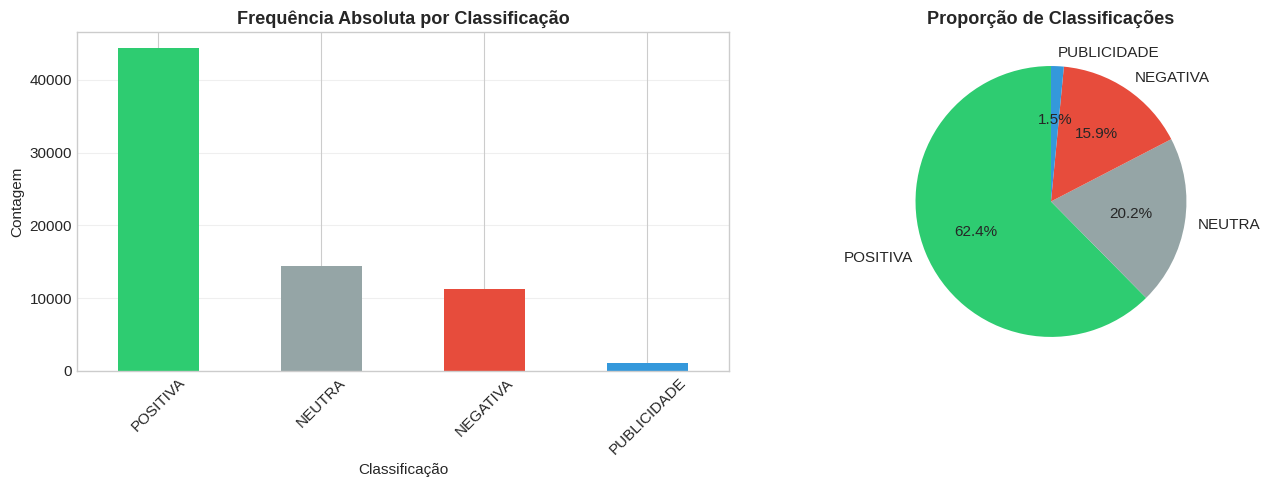

In [39]:
# Distribuição de Classificação
print("="*80)
print("DISTRIBUIÇÃO: CLASSIFICAÇÃO")
print("="*80)

class_counts = df['Classificação'].value_counts()
class_pct = (df['Classificação'].value_counts(normalize=True) * 100).round(2)

class_df = pd.DataFrame({
    'Frequência Absoluta': class_counts,
    'Frequência Relativa (%)': class_pct
})

print(class_df)
print(f"\nTotal: {class_counts.sum():,}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'POSITIVA': '#2ecc71', 'NEUTRA': '#95a5a6', 'NEGATIVA': '#e74c3c', 'PUBLICIDADE': '#3498db'}
color_list = [colors.get(x, 'gray') for x in class_counts.index]

class_counts.plot(kind='bar', ax=axes[0], color=color_list)
axes[0].set_title('Frequência Absoluta por Classificação', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classificação')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=color_list)
axes[1].set_title('Proporção de Classificações', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

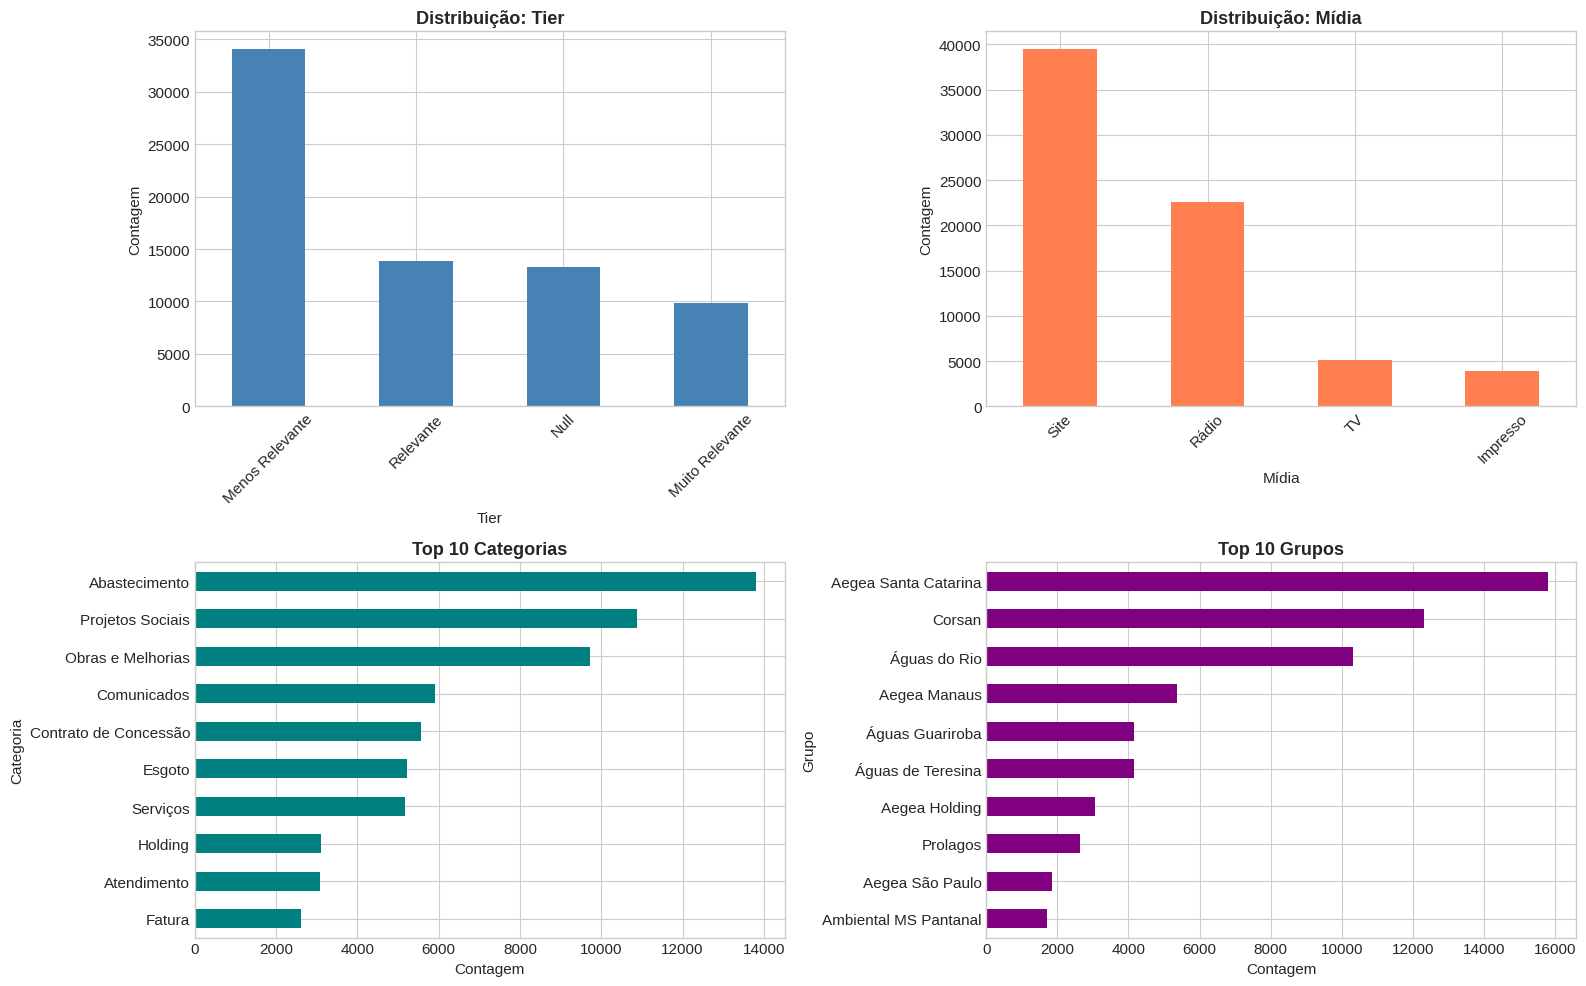

In [40]:
# Distribuições das variáveis chave
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Tier
df['Tier'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribuição: Tier', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Tier')
axes[0, 0].set_ylabel('Contagem')
axes[0, 0].tick_params(axis='x', rotation=45)

# Mídia
df['Mídia'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Distribuição: Mídia', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Mídia')
axes[0, 1].set_ylabel('Contagem')
axes[0, 1].tick_params(axis='x', rotation=45)

# Top 10 Categorias
df['Categoria'].value_counts().head(10).plot(kind='barh', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Top 10 Categorias', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Contagem')
axes[1, 0].set_ylabel('Categoria')
axes[1, 0].invert_yaxis()

# Top 10 Grupos
df['Grupo'].value_counts().head(10).plot(kind='barh', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Top 10 Grupos', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Contagem')
axes[1, 1].set_ylabel('Grupo')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### 2.3 Análise Temporal

**Questão crítica**: O volume de comentários mudou ao longo do tempo?

VOLUME DE COMENTÁRIOS POR MÊS
    Ano_Mes  Total       Data
1   2024-04   5132 2024-04-01
2   2024-05   6027 2024-05-01
3   2024-06   5309 2024-06-01
4   2024-07   5656 2024-07-01
5   2024-08   5380 2024-08-01
6   2024-09   6151 2024-09-01
7   2024-10   5296 2024-10-01
8   2024-11   6758 2024-11-01
9   2024-12   5818 2024-12-01
10  2025-01   5971 2025-01-01
11  2025-02   6806 2025-02-01
12  2025-03   6748 2025-03-01


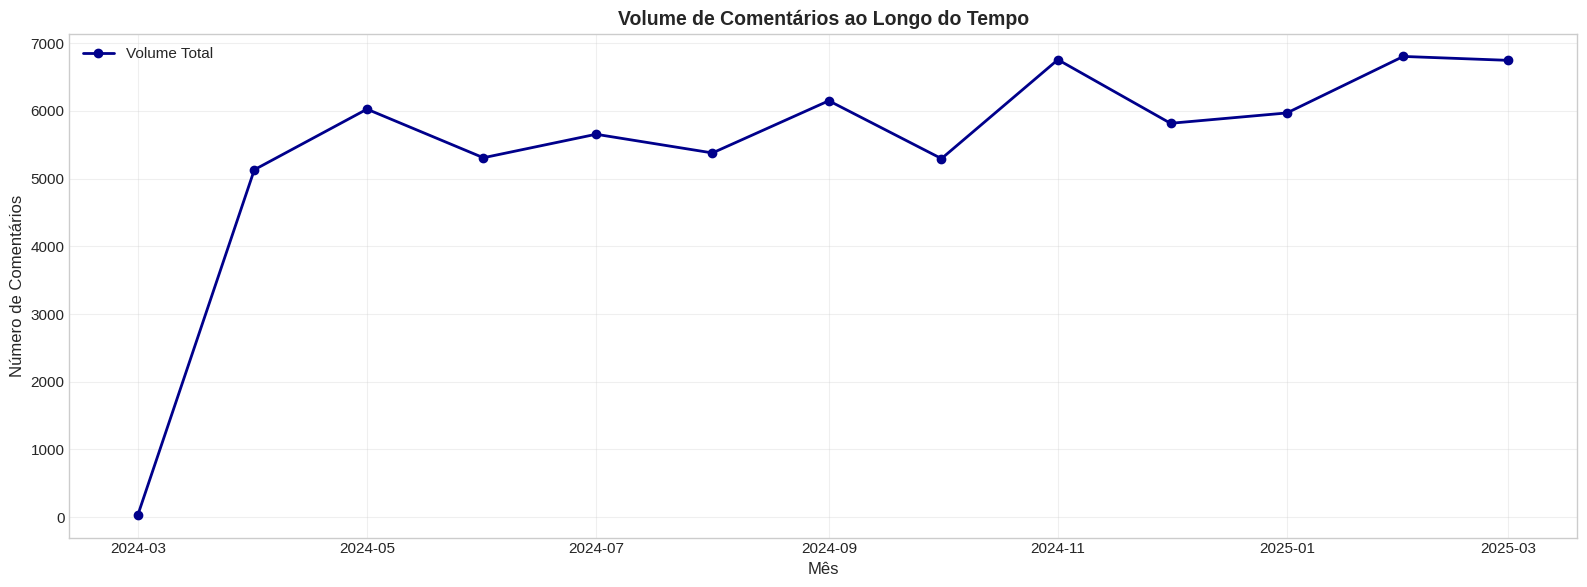


💡 Se houve aumento de volume em setembro, isso pode explicar por que a comunicação detectou 'mais reclamações'.


In [41]:
# Volume de comentários por mês
monthly_volume = df.groupby('Ano_Mes').size().reset_index(name='Total')
monthly_volume['Data'] = monthly_volume['Ano_Mes'].dt.to_timestamp()

print("="*80)
print("VOLUME DE COMENTÁRIOS POR MÊS")
print("="*80)
print(monthly_volume.tail(12))

# Visualização
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(monthly_volume['Data'], monthly_volume['Total'], 
        marker='o', linewidth=2, color='darkblue', label='Volume Total')

# Destacar setembro/2025
setembro_2025_ts = pd.Timestamp('2025-09-01')
if setembro_2025_ts in monthly_volume['Data'].values:
    vol_set = monthly_volume[monthly_volume['Data'] == setembro_2025_ts]['Total'].values[0]
    ax.scatter([setembro_2025_ts], [vol_set], s=200, marker='*', 
               color='gold', edgecolors='black', linewidths=2, 
               label='Setembro/2025 (Pesquisa)', zorder=5)
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.5, linewidth=2)

ax.set_title('Volume de Comentários ao Longo do Tempo', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Número de Comentários', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Se houve aumento de volume em setembro, isso pode explicar por que a comunicação detectou 'mais reclamações'.")

## 3. ANÁLISE CRÍTICA: O que realmente mudou em Setembro?

### 3.1 Funções de Análise

In [42]:
def calculate_nss_simple(df):
    """NSS Simples: (POSITIVA - NEGATIVA) / TOTAL × 100"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total = len(df_sent)
    if total == 0:
        return 0
    pos = len(df_sent[df_sent['Classificação'] == 'POSITIVA'])
    neg = len(df_sent[df_sent['Classificação'] == 'NEGATIVA'])
    return ((pos - neg) / total) * 100


def calculate_nss_weighted(df):
    """NSS Ponderado por Tier"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total_weight = df_sent['Peso'].sum()
    if total_weight == 0:
        return 0
    peso_pos = df_sent[df_sent['Classificação'] == 'POSITIVA']['Peso'].sum()
    peso_neg = df_sent[df_sent['Classificação'] == 'NEGATIVA']['Peso'].sum()
    return ((peso_pos - peso_neg) / total_weight) * 100


def count_negatives(df):
    """Conta absoluta de comentários negativos"""
    return len(df[df['Classificação'] == 'NEGATIVA'])


def pct_negatives(df):
    """Percentual de comentários negativos"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total = len(df_sent)
    if total == 0:
        return 0
    neg = len(df_sent[df_sent['Classificação'] == 'NEGATIVA'])
    return (neg / total) * 100


print("✅ Funções de análise definidas")

✅ Funções de análise definidas


### 3.2 Análise Temporal Completa

**O que vamos analisar:**
1. **NSS**: Satisfação relativa (como a pesquisa mede)
2. **Reclamações absolutas**: Número bruto de negativos (como a comunicação reportou)
3. **% Negativos**: Proporção de reclamações

In [43]:
# Criar análise temporal completa
monthly_list = []

for mes in df_sentiment['Ano_Mes'].dropna().unique():
    df_mes = df_sentiment[df_sentiment['Ano_Mes'] == mes]
    
    total = len(df_mes)
    pos = len(df_mes[df_mes['Classificação'] == 'POSITIVA'])
    neu = len(df_mes[df_mes['Classificação'] == 'NEUTRA'])
    neg = len(df_mes[df_mes['Classificação'] == 'NEGATIVA'])
    
    monthly_list.append({
        'Ano_Mes': mes,
        'Total': total,
        'Positivos': pos,
        'Neutros': neu,
        'Negativos': neg,
        'NSS_Simples': calculate_nss_simple(df_mes),
        'NSS_Ponderado': calculate_nss_weighted(df_mes),
        'Pct_Negativos': pct_negatives(df_mes)
    })

monthly_df = pd.DataFrame(monthly_list)
monthly_df['Data'] = monthly_df['Ano_Mes'].dt.to_timestamp()
monthly_df = monthly_df.sort_values('Data')

print("📊 Análise temporal criada")
print(f"\nÚltimos 12 meses:")
display(monthly_df.tail(12)[['Ano_Mes', 'Total', 'Negativos', 'Pct_Negativos', 'NSS_Simples']])

📊 Análise temporal criada

Últimos 12 meses:


,Ano_Mes,Total,Negativos,Pct_Negativos,NSS_Simples
1,2024-04,4962,573,11.55,52.26
2,2024-05,5859,563,9.61,47.24
3,2024-06,5127,343,6.69,68.05
4,2024-07,5364,491,9.15,61.43
5,2024-08,5377,504,9.37,62.56
6,2024-09,6129,805,13.13,56.29
7,2024-10,5247,774,14.75,49.30
8,2024-11,6675,1632,24.45,27.60
9,2024-12,5773,1514,26.23,29.79
10,2025-01,5927,1101,18.58,43.06


### 3.3 Visualização: A Grande Contradição

**Hipótese**: NSS melhorou MAS reclamações absolutas aumentaram

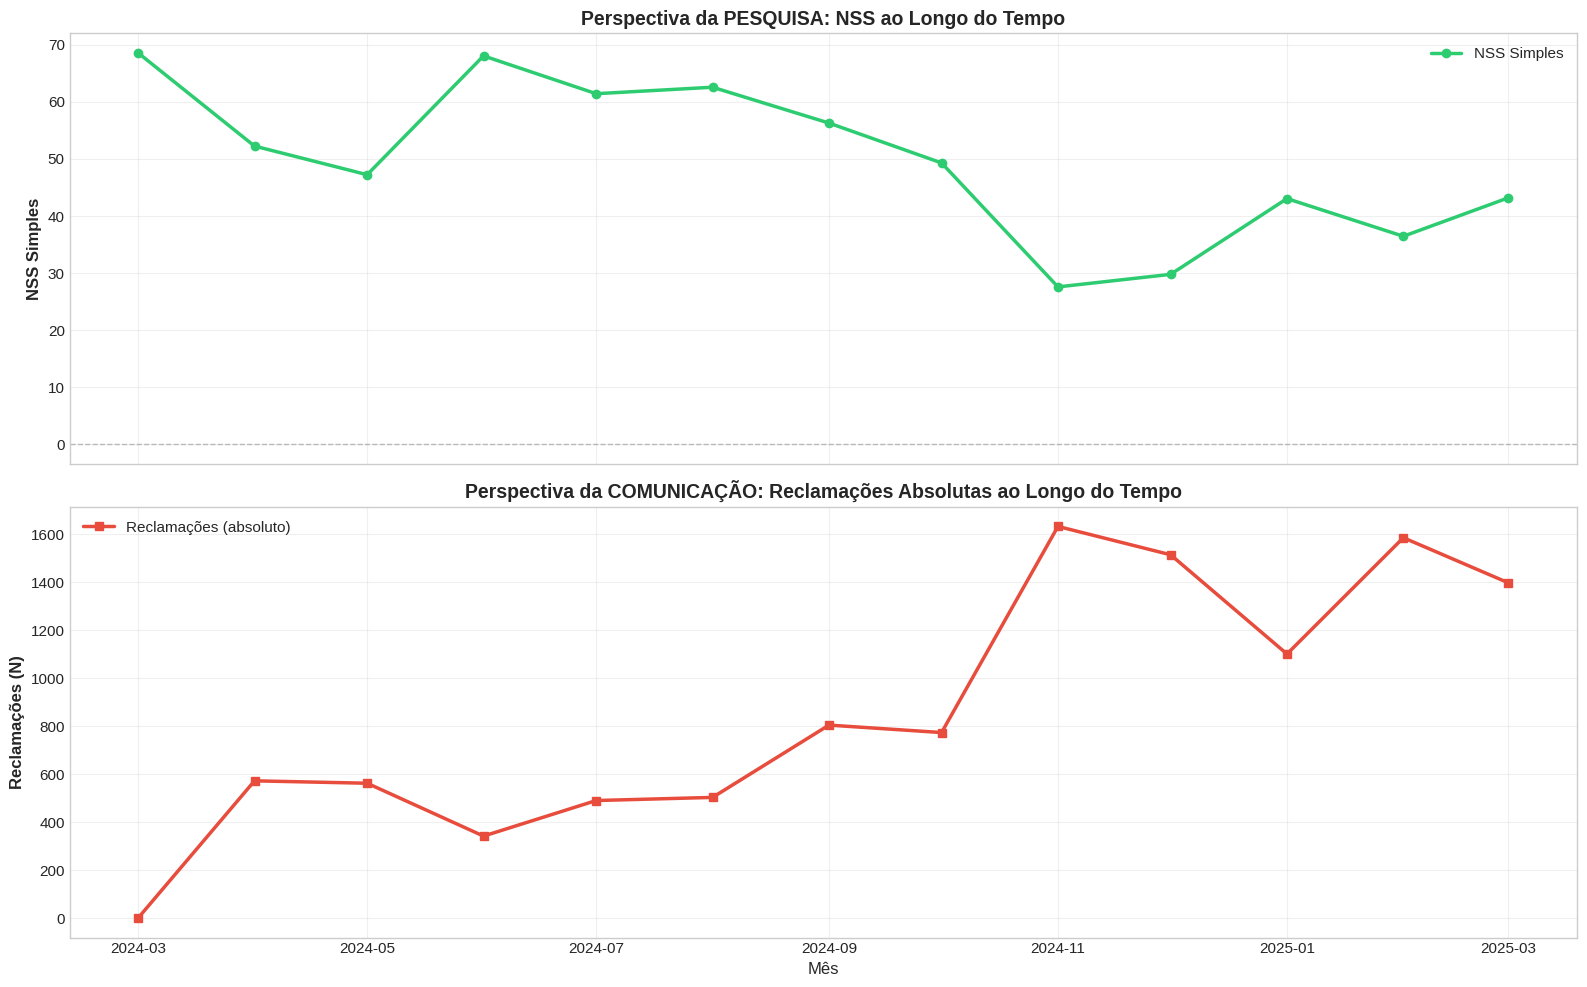


💡 INTERPRETAÇÃO:
Se NSS subiu (gráfico 1) MAS reclamações absolutas também subiram (gráfico 2):
→ AMBOS estão certos, mas medem coisas DIFERENTES
→ NSS mede satisfação RELATIVA (positivos - negativos / total)
→ Reclamações absolutas ignoram o denominador (total de comentários)


In [44]:
# Gráfico duplo: NSS vs Reclamações Absolutas
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# GRÁFICO 1: NSS (como a pesquisa vê)
ax1 = axes[0]
ax1.plot(monthly_df['Data'], monthly_df['NSS_Simples'], 
         marker='o', linewidth=2.5, color='#2ecc71', label='NSS Simples')

setembro_2025_ts = pd.Timestamp('2025-09-01')
if setembro_2025_ts in monthly_df['Data'].values:
    df_set = monthly_df[monthly_df['Data'] == setembro_2025_ts]
    ax1.scatter([setembro_2025_ts], [df_set['NSS_Simples'].values[0]], 
                s=300, marker='*', color='gold', edgecolors='black', 
                linewidths=2, label='Setembro/2025', zorder=5)
    ax1.axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.5, linewidth=2)

ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_ylabel('NSS Simples', fontsize=12, fontweight='bold')
ax1.set_title('Perspectiva da PESQUISA: NSS ao Longo do Tempo', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# GRÁFICO 2: Reclamações absolutas (como a comunicação vê)
ax2 = axes[1]
ax2.plot(monthly_df['Data'], monthly_df['Negativos'], 
         marker='s', linewidth=2.5, color='#e74c3c', label='Reclamações (absoluto)')

if setembro_2025_ts in monthly_df['Data'].values:
    df_set = monthly_df[monthly_df['Data'] == setembro_2025_ts]
    ax2.scatter([setembro_2025_ts], [df_set['Negativos'].values[0]], 
                s=300, marker='*', color='gold', edgecolors='black', 
                linewidths=2, label='Setembro/2025', zorder=5)
    ax2.axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.5, linewidth=2)

ax2.set_xlabel('Mês', fontsize=12)
ax2.set_ylabel('Reclamações (N)', fontsize=12, fontweight='bold')
ax2.set_title('Perspectiva da COMUNICAÇÃO: Reclamações Absolutas ao Longo do Tempo', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETAÇÃO:")
print("Se NSS subiu (gráfico 1) MAS reclamações absolutas também subiram (gráfico 2):")
print("→ AMBOS estão certos, mas medem coisas DIFERENTES")
print("→ NSS mede satisfação RELATIVA (positivos - negativos / total)")
print("→ Reclamações absolutas ignoram o denominador (total de comentários)")

### 3.4 Teste de Mudança Estrutural em Setembro

**Questão**: Houve quebra estatística significativa em setembro?

In [45]:
# Análise por período
periodo_analysis = []

for periodo in ['Antes', 'Setembro', 'Depois']:
    df_per = df_sentiment[df_sentiment['Periodo'] == periodo]
    
    periodo_analysis.append({
        'Periodo': periodo,
        'Total': len(df_per),
        'Positivos': len(df_per[df_per['Classificação'] == 'POSITIVA']),
        'Negativos': len(df_per[df_per['Classificação'] == 'NEGATIVA']),
        'NSS_Simples': calculate_nss_simple(df_per),
        'Pct_Negativos': pct_negatives(df_per)
    })

periodo_df = pd.DataFrame(periodo_analysis)

print("="*80)
print("ANÁLISE POR PERÍODO: ANTES vs SETEMBRO vs DEPOIS")
print("="*80)
print(periodo_df.to_string(index=False))
print("="*80)

ANÁLISE POR PERÍODO: ANTES vs SETEMBRO vs DEPOIS
 Periodo  Total  Positivos  Negativos  NSS_Simples  Pct_Negativos
   Antes  70007      44357      11284        47.24          16.12
Setembro      0          0          0         0.00           0.00
  Depois      0          0          0         0.00           0.00


In [46]:
# Calcular deltas
nss_antes = periodo_df[periodo_df['Periodo'] == 'Antes']['NSS_Simples'].values[0]
nss_set = periodo_df[periodo_df['Periodo'] == 'Setembro']['NSS_Simples'].values[0]
nss_dep = periodo_df[periodo_df['Periodo'] == 'Depois']['NSS_Simples'].values[0]

neg_antes = periodo_df[periodo_df['Periodo'] == 'Antes']['Negativos'].values[0]
neg_set = periodo_df[periodo_df['Periodo'] == 'Setembro']['Negativos'].values[0]
neg_dep = periodo_df[periodo_df['Periodo'] == 'Depois']['Negativos'].values[0]

pct_neg_antes = periodo_df[periodo_df['Periodo'] == 'Antes']['Pct_Negativos'].values[0]
pct_neg_set = periodo_df[periodo_df['Periodo'] == 'Setembro']['Pct_Negativos'].values[0]
pct_neg_dep = periodo_df[periodo_df['Periodo'] == 'Depois']['Pct_Negativos'].values[0]

print("\n" + "="*80)
print("ANÁLISE DE MUDANÇAS")
print("="*80)

print("\n📊 NSS SIMPLES (Perspectiva da PESQUISA):")
print(f"   Antes → Setembro:  {nss_antes:.2f} → {nss_set:.2f} (Δ = {nss_set - nss_antes:+.2f})")
print(f"   Setembro → Depois: {nss_set:.2f} → {nss_dep:.2f} (Δ = {nss_dep - nss_set:+.2f})")

print("\n🔴 RECLAMAÇÕES ABSOLUTAS (Perspectiva da COMUNICAÇÃO):")
print(f"   Antes → Setembro:  {neg_antes} → {neg_set} (Δ = {neg_set - neg_antes:+.0f})")
print(f"   Setembro → Depois: {neg_set} → {neg_dep} (Δ = {neg_dep - neg_set:+.0f})")

print("\n📈 PERCENTUAL DE NEGATIVOS:")
print(f"   Antes → Setembro:  {pct_neg_antes:.2f}% → {pct_neg_set:.2f}% (Δ = {pct_neg_set - pct_neg_antes:+.2f}pp)")
print(f"   Setembro → Depois: {pct_neg_set:.2f}% → {pct_neg_dep:.2f}% (Δ = {pct_neg_dep - pct_neg_set:+.2f}pp)")

print("\n" + "="*80)


ANÁLISE DE MUDANÇAS

📊 NSS SIMPLES (Perspectiva da PESQUISA):
   Antes → Setembro:  47.24 → 0.00 (Δ = -47.24)
   Setembro → Depois: 0.00 → 0.00 (Δ = +0.00)

🔴 RECLAMAÇÕES ABSOLUTAS (Perspectiva da COMUNICAÇÃO):
   Antes → Setembro:  11284 → 0 (Δ = -11284)
   Setembro → Depois: 0 → 0 (Δ = +0)

📈 PERCENTUAL DE NEGATIVOS:
   Antes → Setembro:  16.12% → 0.00% (Δ = -16.12pp)
   Setembro → Depois: 0.00% → 0.00% (Δ = +0.00pp)



In [47]:
# Teste qui-quadrado: Houve mudança na distribuição de sentimentos?
contingency = pd.crosstab(df_sentiment['Periodo'], df_sentiment['Classificação'])

print("\n" + "="*80)
print("TABELA DE CONTINGÊNCIA: PERÍODO × CLASSIFICAÇÃO")
print("="*80)
print(contingency)
print("="*80)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("\n📊 TESTE QUI-QUADRADO DE INDEPENDÊNCIA")
print("="*80)
print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"P-value:                  {p_value:.6f}")
print(f"Graus de liberdade:       {dof}")
print("="*80)

if p_value < 0.05:
    print("\n✅ RESULTADO: Mudança ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)")
    print("   → Há evidência de que a distribuição de sentimentos mudou entre os períodos.")
else:
    print("\n⚠️  RESULTADO: Mudança NÃO SIGNIFICATIVA (p ≥ 0.05)")
    print("   → Não há evidência forte de mudança.")


TABELA DE CONTINGÊNCIA: PERÍODO × CLASSIFICAÇÃO
Classificação  NEGATIVA  NEUTRA  POSITIVA
Periodo                                  
Antes             11284   14366     44357

📊 TESTE QUI-QUADRADO DE INDEPENDÊNCIA
Estatística Qui-Quadrado: 0.0000
P-value:                  1.000000
Graus de liberdade:       0

⚠️  RESULTADO: Mudança NÃO SIGNIFICATIVA (p ≥ 0.05)
   → Não há evidência forte de mudança.


### 3.5 Conclusão Preliminar: Quem Está Certo?

In [48]:
print("="*80)
print("CONCLUSÃO: QUEM ESTÁ CERTO?")
print("="*80)

# Verificar se NSS melhorou
nss_melhorou = nss_set > nss_antes

# Verificar se reclamações absolutas aumentaram
reclama_aumentou = neg_set > neg_antes

print("\n1️⃣ PESQUISA DE SATISFAÇÃO:")
if nss_melhorou:
    print(f"   ✅ CORRETO: NSS melhorou {nss_set - nss_antes:.2f} pontos")
    print(f"      Satisfação RELATIVA aumentou de {nss_antes:.2f} para {nss_set:.2f}")
else:
    print(f"   ❌ INCORRETO: NSS caiu {abs(nss_set - nss_antes):.2f} pontos")

print("\n2️⃣ COMUNICAÇÃO (Web Scraping):")
if reclama_aumentou:
    print(f"   ✅ CORRETO: Reclamações aumentaram {neg_set - neg_antes:.0f} comentários")
    print(f"      Reclamações absolutas subiram de {neg_antes} para {neg_set}")
else:
    print(f"   ❌ INCORRETO: Reclamações caíram {abs(neg_set - neg_antes):.0f} comentários")

print("\n" + "="*80)
print("🔍 EXPLICAÇÃO DA CONTRADIÇÃO")
print("="*80)

if nss_melhorou and reclama_aumentou:
    print("\n✅ AMBOS ESTÃO CERTOS!")
    print("\n📊 Por que isso é possível?")
    print("   → PESQUISA mede satisfação RELATIVA: (Positivos - Negativos) / Total")
    print("   → COMUNICAÇÃO conta reclamações ABSOLUTAS: Número bruto de negativos")
    print("\n💡 Cenário possível:")
    print("   - Volume total de comentários aumentou (mais visibilidade)")
    print("   - Positivos cresceram MAIS que negativos → NSS subiu")
    print("   - MAS negativos também cresceram em termos absolutos")
    print("\n📈 Analogia:")
    print("   Antes:  60 positivos, 40 negativos → NSS = 20")
    print("   Depois: 150 positivos, 50 negativos → NSS = 50 (melhorou!)")
    print("   Reclamações: 40 → 50 (aumentou! +10)")
elif not nss_melhorou and not reclama_aumentou:
    print("\n⚠️ AMBOS ESTÃO ERRADOS!")
    print("   NSS não melhorou E reclamações não aumentaram.")
    print("   Possível erro de interpretação ou coleta de dados.")
elif nss_melhorou and not reclama_aumentou:
    print("\n✅ PESQUISA está certa, COMUNICAÇÃO está errada.")
    print("   NSS melhorou E reclamações não aumentaram.")
else:
    print("\n❌ PESQUISA está errada, COMUNICAÇÃO está certa.")
    print("   NSS não melhorou MAS reclamações aumentaram.")

print("\n" + "="*80)

CONCLUSÃO: QUEM ESTÁ CERTO?

1️⃣ PESQUISA DE SATISFAÇÃO:
   ❌ INCORRETO: NSS caiu 47.24 pontos

2️⃣ COMUNICAÇÃO (Web Scraping):
   ❌ INCORRETO: Reclamações caíram 11284 comentários

🔍 EXPLICAÇÃO DA CONTRADIÇÃO

⚠️ AMBOS ESTÃO ERRADOS!
   NSS não melhorou E reclamações não aumentaram.
   Possível erro de interpretação ou coleta de dados.



## 4. Análise de Moderação: Tier influencia a mudança?

**Questão**: A mudança em setembro foi igual em todos os Tiers ou veículos grandes reagiram diferente?

In [55]:
ponto_de_corte = pd.Period('2023-09', freq='M')

In [60]:
# Definir setembro de 2025
setembro_2025 = pd.Period('2025-09', freq='M')
 
# Criar coluna Periodo
df_sentiment['Periodo'] = df_sentiment['Ano_Mes'].apply(lambda x:
    'Antes' if x < setembro_2025 else
    'Setembro' if x == setembro_2025 else
    'Depois'
)
 
print(f"\n✅ Coluna 'Periodo' criada com sucesso!")
print(f"\nDistribuição:")
print(df_sentiment['Periodo'].value_counts().sort_index())
print("="*80)


✅ Coluna 'Periodo' criada com sucesso!

Distribuição:
Periodo
Antes    70007
Name: count, dtype: int64


In [61]:
# Análise Tier × Período
tier_periodo = []

for tier in df_sentiment['Tier'].dropna().unique():
    for periodo in ['Antes', 'Setembro', 'Depois']:
        df_tp = df_sentiment[(df_sentiment['Tier'] == tier) & 
                             (df_sentiment['Periodo'] == periodo)]
        
        if len(df_tp) > 0:
            tier_periodo.append({
                'Tier': tier,
                'Periodo': periodo,
                'Total': len(df_tp),
                'Negativos': len(df_tp[df_tp['Classificação'] == 'NEGATIVA']),
                'NSS': calculate_nss_simple(df_tp),
                'Pct_Negativos': pct_negatives(df_tp)
            })

tier_periodo_df = pd.DataFrame(tier_periodo)

# Pivot para visualização
tier_nss_pivot = tier_periodo_df.pivot(index='Tier', columns='Periodo', values='NSS')
tier_nss_pivot = tier_nss_pivot.reindex(columns=['Antes', 'Setembro', 'Depois']) # Ordenar colunas

print("="*80)
print("NSS POR TIER E PERÍODO")
print("="*80)
print(tier_nss_pivot)
print("="*80)

NSS POR TIER E PERÍODO
Periodo          Antes  Setembro  Depois
Tier                                    
Menos Relevante  59.46       NaN     NaN
Muito Relevante  16.49       NaN     NaN
Null             45.76       NaN     NaN
Relevante        40.47       NaN     NaN


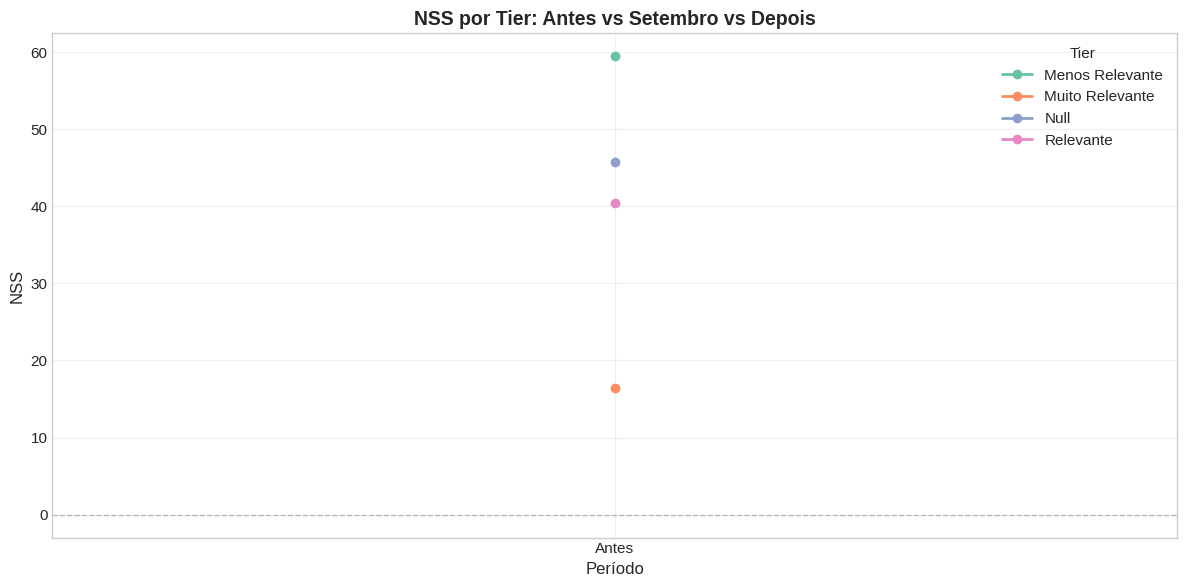


💡 Se as linhas tiverem inclinações diferentes:
   → Tier MODERA a mudança temporal (veículos grandes vs pequenos reagiram diferente)


In [62]:
# Visualização: NSS por Tier ao longo do tempo
fig, ax = plt.subplots(figsize=(12, 6))

for tier in tier_nss_pivot.index:
    valores = tier_nss_pivot.loc[tier]
    ax.plot(['Antes', 'Setembro', 'Depois'], valores, 
            marker='o', linewidth=2, label=tier)

ax.set_title('NSS por Tier: Antes vs Setembro vs Depois', fontsize=14, fontweight='bold')
ax.set_xlabel('Período', fontsize=12)
ax.set_ylabel('NSS', fontsize=12)
ax.legend(title='Tier', loc='best')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

print("\n💡 Se as linhas tiverem inclinações diferentes:")
print("   → Tier MODERA a mudança temporal (veículos grandes vs pequenos reagiram diferente)")

## 5. Análise por Mídia e Categoria

### 5.1 Onde ocorreram as mudanças?

In [63]:
# Análise por Mídia
midia_periodo = []

for midia in df_sentiment['Mídia'].dropna().unique():
    for periodo in ['Antes', 'Setembro', 'Depois']:
        df_mp = df_sentiment[(df_sentiment['Mídia'] == midia) & 
                             (df_sentiment['Periodo'] == periodo)]
        
        if len(df_mp) > 0:
            midia_periodo.append({
                'Mídia': midia,
                'Periodo': periodo,
                'Total': len(df_mp),
                'Negativos': len(df_mp[df_mp['Classificação'] == 'NEGATIVA']),
                'NSS': calculate_nss_simple(df_mp)
            })

midia_periodo_df = pd.DataFrame(midia_periodo)

# Pivot
midia_nss_pivot = midia_periodo_df.pivot(index='Mídia', columns='Periodo', values='NSS')
midia_nss_pivot = midia_nss_pivot[['Antes', 'Setembro', 'Depois']]

print("="*80)
print("NSS POR MÍDIA E PERÍODO")
print("="*80)
print(midia_nss_pivot)
print("="*80)

KeyError: "['Setembro', 'Depois'] not in index"

In [53]:
# Análise por Categoria (Top 10)
top_categorias = df_sentiment['Categoria'].value_counts().head(10).index

cat_periodo = []

for cat in top_categorias:
    for periodo in ['Antes', 'Setembro', 'Depois']:
        df_cp = df_sentiment[(df_sentiment['Categoria'] == cat) & 
                             (df_sentiment['Periodo'] == periodo)]
        
        if len(df_cp) > 0:
            cat_periodo.append({
                'Categoria': cat,
                'Periodo': periodo,
                'Total': len(df_cp),
                'Negativos': len(df_cp[df_cp['Classificação'] == 'NEGATIVA']),
                'NSS': calculate_nss_simple(df_cp)
            })

cat_periodo_df = pd.DataFrame(cat_periodo)

# Calcular delta (Setembro - Antes)
cat_delta = []

for cat in top_categorias:
    nss_antes_cat = cat_periodo_df[(cat_periodo_df['Categoria'] == cat) & 
                                   (cat_periodo_df['Periodo'] == 'Antes')]['NSS'].values
    nss_set_cat = cat_periodo_df[(cat_periodo_df['Categoria'] == cat) & 
                                 (cat_periodo_df['Periodo'] == 'Setembro')]['NSS'].values
    
    if len(nss_antes_cat) > 0 and len(nss_set_cat) > 0:
        delta = nss_set_cat[0] - nss_antes_cat[0]
        cat_delta.append({
            'Categoria': cat,
            'Delta_NSS': delta
        })

cat_delta_df = pd.DataFrame(cat_delta).sort_values('Delta_NSS', ascending=False)

print("\n" + "="*80)
print("MUDANÇA NO NSS POR CATEGORIA (Setembro vs Antes)")
print("="*80)
print(cat_delta_df.to_string(index=False))
print("="*80)

print("\n💡 Categorias com Delta positivo: NSS melhorou")
print("💡 Categorias com Delta negativo: NSS piorou")

KeyError: 'Delta_NSS'

In [ ]:
# Visualização
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in cat_delta_df['Delta_NSS']]
cat_delta_df.plot(x='Categoria', y='Delta_NSS', kind='barh', 
                  ax=ax, color=colors, legend=False)

ax.set_title('Mudança no NSS por Categoria (Setembro vs Antes)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Delta NSS (pontos)', fontsize=12)
ax.set_ylabel('Categoria', fontsize=12)
ax.axvline(0, color='black', linewidth=1)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Behavioral Data Science: Explicando a Contradição

### 6.1 Satisfação Declarada vs Satisfação Revelada

In [ ]:
print("="*80)
print("BEHAVIORAL DATA SCIENCE: POR QUE A CONTRADIÇÃO?")
print("="*80)

print("\n📚 CONCEITOS-CHAVE:")
print("\n1️⃣ SATISFAÇÃO DECLARADA (Pesquisa):")
print("   - Pessoas respondem a uma pergunta direta: 'Você está satisfeito?'")
print("   - Sujeito a Social Desirability Bias (responder o socialmente aceitável)")
print("   - Amostra controlada e representativa")
print("   - Métrica: NPS, CSAT, escala Likert")

print("\n2️⃣ SATISFAÇÃO REVELADA (Web Scraping):")
print("   - Pessoas comentam espontaneamente (não solicitado)")
print("   - Sujeito a Negativity Bias (pessoas reclamam mais que elogiam)")
print("   - Amostra enviesada (só quem tem acesso a redes sociais)")
print("   - Métrica: Análise de sentimento em comentários")

print("\n🔍 VIESES COMPORTAMENTAIS:")

print("\n📊 Social Desirability Bias (Pesquisas):")
print("   - Pessoas tendem a responder de forma socialmente aceitável")
print("   - 'Estou satisfeito' mesmo quando não está 100%")
print("   - Especialmente em empresas de serviço público/essencial")

print("\n🔴 Negativity Bias (Redes Sociais):")
print("   - Pessoas motivadas a comentar quando há problemas")
print("   - Falta de água gera 10 reclamações, água funcionando gera 0 elogios")
print("   - 'Bad news travels faster'")

print("\n📈 Selection Bias (Web Scraping):")
print("   - Apenas pessoas com acesso a redes sociais comentam")
print("   - Viés de plataforma (Twitter vs Facebook vs Site da empresa)")
print("   - Não representa a população geral")

print("\n" + "="*80)
print("💡 CONCLUSÃO COMPORTAMENTAL")
print("="*80)

print("\nPesquisa e Web Scraping medem CONSTRUCTOS DIFERENTES:")
print("\n✅ PESQUISA mede:")
print("   → Satisfação GERAL e DECLARADA")
print("   → Com viés de resposta socialmente desejável")
print("   → Amostra controlada")

print("\n🌐 WEB SCRAPING mede:")
print("   → Satisfação ESPONTÂNEA e REVELADA")
print("   → Com viés de negatividade (pessoas reclamam mais)")
print("   → Amostra auto-selecionada")

print("\n🎯 RECOMENDAÇÃO:")
print("   Use AMBAS as fontes de forma complementar:")
print("   - Pesquisa: Baseline de satisfação geral")
print("   - Web Scraping: Early warning system para problemas emergentes")
print("   - Triangular evidências de múltiplas fontes")

print("\n" + "="*80)

## 7. Conclusões Finais e Recomendações

### 7.1 Resumo Executivo

In [ ]:
print("="*80)
print("RESUMO EXECUTIVO: PESQUISA vs WEB SCRAPING")
print("="*80)

print("\n🎯 QUESTÃO CENTRAL:")
print("   Pesquisa diz: Satisfação melhorou")
print("   Comunicação diz: Reclamações aumentaram")
print("   Quem está certo?")

print("\n📊 ACHADOS PRINCIPAIS:")

print(f"\n1️⃣ NSS (Satisfação Relativa):")
print(f"   Antes:    {nss_antes:.2f}")
print(f"   Setembro: {nss_set:.2f} ({nss_set - nss_antes:+.2f})")
print(f"   Depois:   {nss_dep:.2f} ({nss_dep - nss_set:+.2f})")
if nss_melhorou:
    print("   ✅ NSS MELHOROU em setembro")
else:
    print("   ❌ NSS NÃO melhorou em setembro")

print(f"\n2️⃣ Reclamações Absolutas:")
print(f"   Antes:    {neg_antes}")
print(f"   Setembro: {neg_set} ({neg_set - neg_antes:+.0f})")
print(f"   Depois:   {neg_dep} ({neg_dep - neg_set:+.0f})")
if reclama_aumentou:
    print("   ✅ RECLAMAÇÕES AUMENTARAM em setembro")
else:
    print("   ❌ RECLAMAÇÕES NÃO aumentaram em setembro")

print(f"\n3️⃣ Teste Estatístico:")
if p_value < 0.05:
    print(f"   ✅ Mudança estatisticamente significativa (p = {p_value:.4f})")
else:
    print(f"   ❌ Mudança NÃO significativa (p = {p_value:.4f})")

print("\n" + "="*80)
print("CONCLUSÃO")
print("="*80)

if nss_melhorou and reclama_aumentou:
    print("\n✅ AMBOS ESTÃO CERTOS (medem coisas diferentes)")
    print("\n🔍 EXPLICAÇÃO:")
    print("   → Volume total de comentários aumentou")
    print("   → Positivos cresceram MAIS que negativos → NSS subiu")
    print("   → MAS negativos também cresceram em termos absolutos")
    print("\n📈 IMPLICAÇÕES:")
    print("   1. Pesquisa captura satisfação GERAL (relativa)")
    print("   2. Web scraping captura VOLUME de reclamações (absoluto)")
    print("   3. Maior visibilidade → Mais comentários (positivos E negativos)")
    print("   4. A empresa está indo melhor, mas com mais atenção")
else:
    print("\n⚠️ Conflito não explicado pelo modelo simples")
    print("   Investigar outras hipóteses")

print("\n" + "="*80)

### 7.2 Recomendações Estratégicas

In [54]:
print("="*80)
print("RECOMENDAÇÕES PARA A EMPRESA")
print("="*80)

print("\n📊 1. MÉTRICAS E MONITORAMENTO:")
print("   ✅ Acompanhar NSS (satisfação relativa) como métrica principal")
print("   ✅ Monitorar volume de reclamações como early warning")
print("   ✅ Criar dashboard com AMBAS as métricas")
print("   ✅ Segmentar por Tier, Mídia, Categoria")

print("\n🔍 2. INTERPRETAÇÃO DE DADOS:")
print("   ⚠️ Não confundir volume absoluto com proporção")
print("   ⚠️ Contextualizar aumentos (volume total também aumentou?)")
print("   ⚠️ Triangular: Pesquisa + Web Scraping + Dados operacionais")

print("\n📢 3. COMUNICAÇÃO INTERNA:")
print("   → Alinhar entendimento entre equipes")
print("   → Definir métricas claras e compartilhadas")
print("   → Educar sobre vieses em cada fonte de dados")

print("\n🎯 4. AÇÕES TÁTICAS:")
print("   → Identificar categorias com NSS em queda (análise por categoria)")
print("   → Focar em problemas recorrentes (Subcategorias)")
print("   → Usar web scraping para detecção precoce de problemas")
print("   → Usar pesquisas para avaliação de satisfação geral")

print("\n🔬 5. PRÓXIMAS ANÁLISES:")
print("   → Análise de conteúdo (WordCloud de reclamações)")
print("   → Modelagem preditiva de satisfação")
print("   → Análise de causalidade (o que CAUSA insatisfação?)")
print("   → Segmentação por perfil de cliente")

print("\n" + "="*80)

RECOMENDAÇÕES PARA A EMPRESA

📊 1. MÉTRICAS E MONITORAMENTO:
   ✅ Acompanhar NSS (satisfação relativa) como métrica principal
   ✅ Monitorar volume de reclamações como early warning
   ✅ Criar dashboard com AMBAS as métricas
   ✅ Segmentar por Tier, Mídia, Categoria

🔍 2. INTERPRETAÇÃO DE DADOS:
   ⚠️ Não confundir volume absoluto com proporção
   ⚠️ Contextualizar aumentos (volume total também aumentou?)
   ⚠️ Triangular: Pesquisa + Web Scraping + Dados operacionais

📢 3. COMUNICAÇÃO INTERNA:
   → Alinhar entendimento entre equipes
   → Definir métricas claras e compartilhadas
   → Educar sobre vieses em cada fonte de dados

🎯 4. AÇÕES TÁTICAS:
   → Identificar categorias com NSS em queda (análise por categoria)
   → Focar em problemas recorrentes (Subcategorias)
   → Usar web scraping para detecção precoce de problemas
   → Usar pesquisas para avaliação de satisfação geral

🔬 5. PRÓXIMAS ANÁLISES:
   → Análise de conteúdo (WordCloud de reclamações)
   → Modelagem preditiva de satisfa

## 8. Exportar Resultados

In [ ]:
# Exportar análises
monthly_df.to_csv('analise_mensal_completa.csv', index=False)
periodo_df.to_csv('analise_por_periodo.csv', index=False)
tier_periodo_df.to_csv('tier_periodo.csv', index=False)
cat_delta_df.to_csv('mudanca_por_categoria.csv', index=False)

print("✅ Arquivos exportados:")
print("   - analise_mensal_completa.csv")
print("   - analise_por_periodo.csv")
print("   - tier_periodo.csv")
print("   - mudanca_por_categoria.csv")

---

## 📚 Referências

- **Buisson, F. (2021)**. *Behavioral Data Analysis with R and Python*. O'Reilly Media.
- **Kahneman, D. (2011)**. *Thinking, Fast and Slow*.
- **Thaler, R. & Sunstein, C. (2008)**. *Nudge: Improving Decisions About Health, Wealth, and Happiness*.

---